In [4]:
from google.colab import files
uploaded = files.upload()

Saving truevsfakenews.csv to truevsfakenews.csv


In [5]:
import pandas as pd

df = pd.read_csv("truevsfakenews.csv")

df.head()

,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


In [6]:
print(df.shape)
print(df.columns)
print(df['label'].value_counts())
df.head()

(20000, 2)
Index(['text', 'label'], dtype='object')
label
true    10000
fake    10000
Name: count, dtype: int64


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


In [7]:
df = df[['text', 'label']]
df = df.dropna()

print(df.shape)
print(df['label'].value_counts())

(20000, 2)
label
true    10000
fake    10000
Name: count, dtype: int64


In [8]:
df['label_encoded'] = df['label'].map({
    'fake': 0,
    'true': 1
})

df.head()

,text,label,label_encoded
0,WASHINGTON (Reuters) - The Republican and Demo...,true,1
1,Women should get as far away from Oklahoma as ...,fake,0
2,Another huge crowd of Americans tuned in last ...,fake,0
3,Donald Trump is desperate to stop the investig...,fake,0
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true,1


In [9]:
df['label_encoded'].value_counts()

,count
label_encoded,
1,10000
0,10000


In [10]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.9 MB/s eta 0:00:00


Cleaning text

In [11]:
import re
import nltk
import contractions

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+', '', text)                    # remove mentions
    text = re.sub(r'#', '', text)                       # remove hashtag symbol
    text = re.sub(r'[^a-z\s]', '', text)                # remove numbers/special chars
    text = re.sub(r'\s+', ' ', text).strip()            # remove extra spaces

    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text', 'label_encoded']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,text,clean_text,label_encoded
0,WASHINGTON (Reuters) - The Republican and Demo...,washington reuters republican democratic leade...,1
1,Women should get as far away from Oklahoma as ...,woman get far away oklahoma soon possible chri...,0
2,Another huge crowd of Americans tuned in last ...,another huge crowd american tuned last week re...,0
3,Donald Trump is desperate to stop the investig...,donald trump desperate stop investigation dirt...,0
4,"(Reuters) - Planned Parenthood, the U.S. medic...",reuters planned parenthood yous medical servic...,1


Checking cleaned dataset

In [12]:
df['clean_text'].head()

,clean_text
0,washington reuters republican democratic leade...
1,woman get far away oklahoma soon possible chri...
2,another huge crowd american tuned last week re...
3,donald trump desperate stop investigation dirt...
4,reuters planned parenthood yous medical servic...


Train-Test-Split

In [13]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16000
Testing samples: 4000


Visualize label distribution

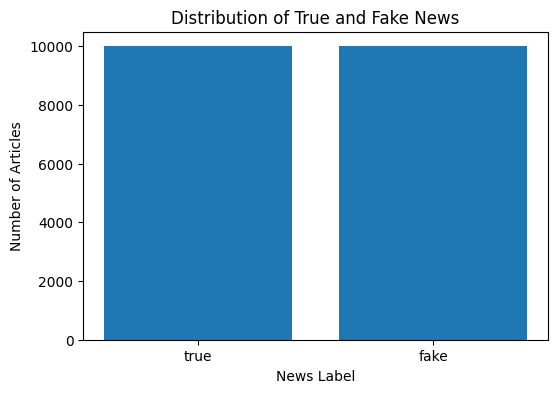

label
true    10000
fake    10000
Name: count, dtype: int64


In [14]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("News Label")
plt.ylabel("Number of Articles")
plt.title("Distribution of True and Fake News")
plt.show()

print(label_counts)

Top 20 most frequent words after cleaning

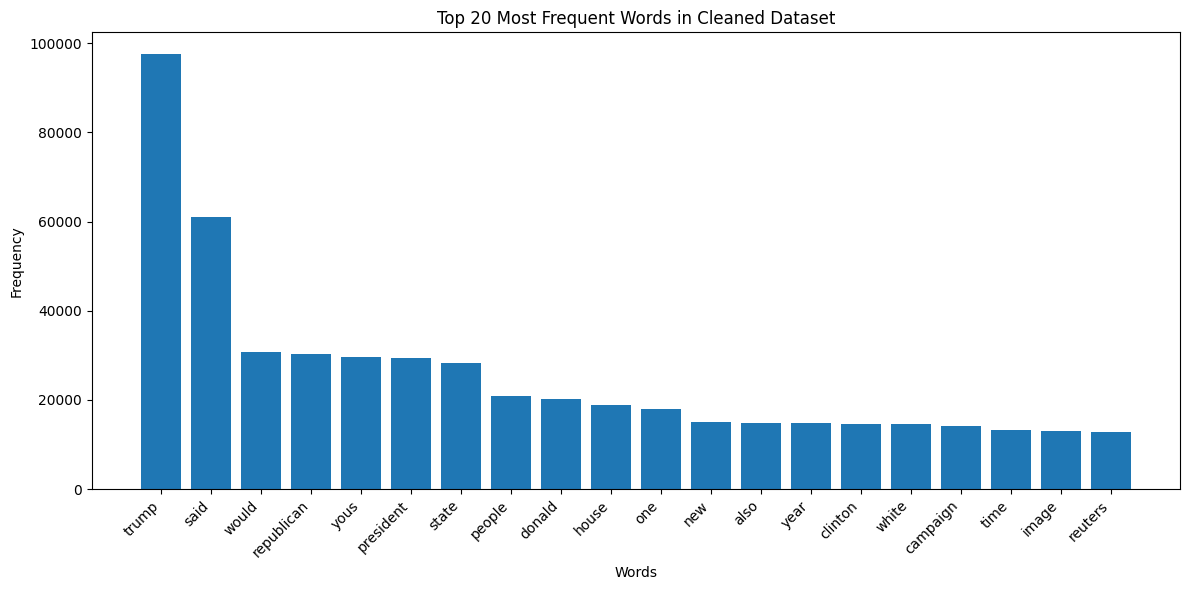

In [15]:
from collections import Counter

all_words = " ".join(df["clean_text"]).split()
word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

words = [word for word, count in common_words]
counts = [count for word, count in common_words]

plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words in Cleaned Dataset")
plt.tight_layout()
plt.show()

Word cloud of cleaned dataset

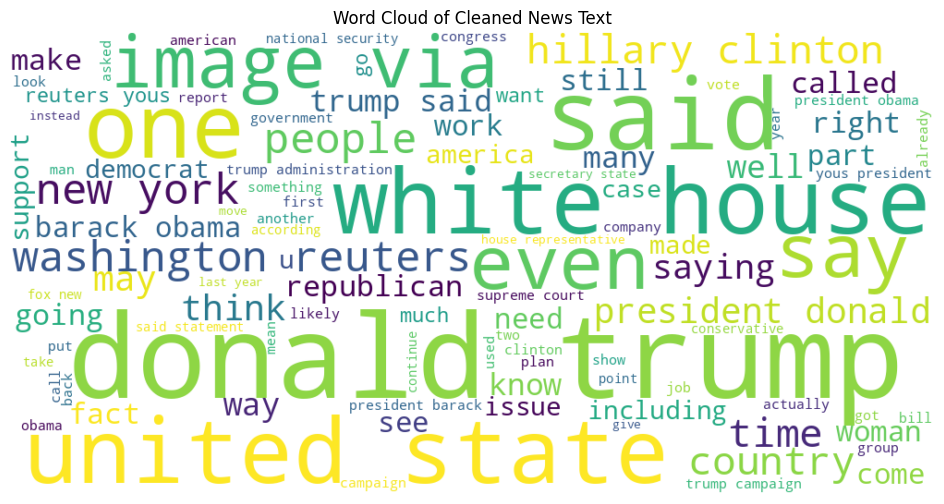

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_data = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(text_data)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned News Text")
plt.show()

True vs Fake word clouds

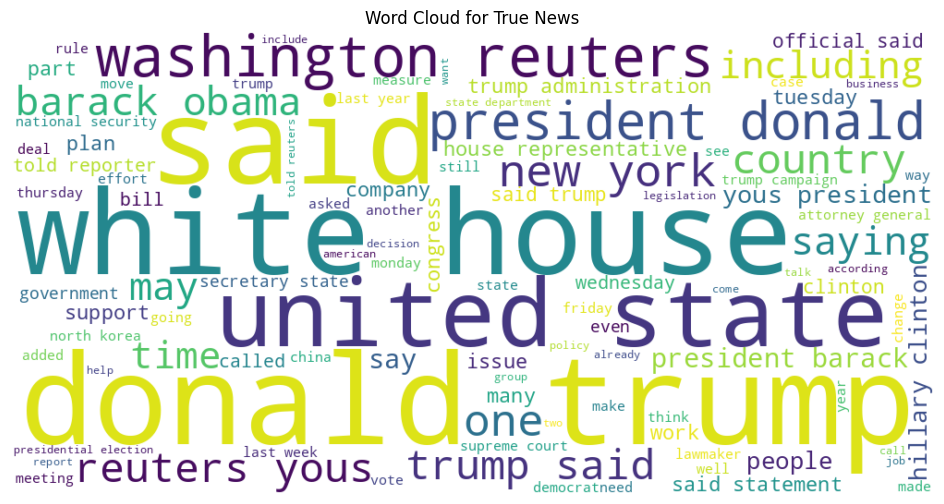

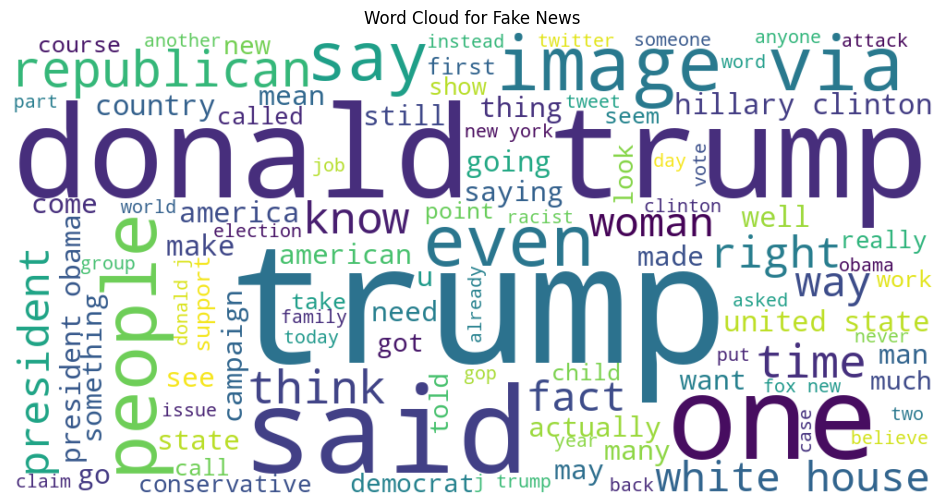

In [17]:
true_text = " ".join(df[df["label_encoded"] == 1]["clean_text"])
fake_text = " ".join(df[df["label_encoded"] == 0]["clean_text"])

true_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(true_text)

fake_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(true_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for True News")
plt.show()

plt.figure(figsize=(12,6))
plt.imshow(fake_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Fake News")
plt.show()

Tokenization and padding

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

MAX_WORDS = 20000
EMBEDDING_DIM = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))

print("95th percentile sequence length:", MAX_LEN)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(X_train_pad.shape)
print(X_test_pad.shape)

95th percentile sequence length: 493
(16000, 493)
(4000, 493)


Model 1: Simple RNN with trainable Embedding layer.

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time

VOCAB_SIZE = 20000
EMBEDDING_DIM = 100

rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training the model

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    callbacks=[early_stop]
)

rnn_training_time = time.time() - start_time
print("RNN training time:", rnn_training_time, "seconds")

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.5138 - loss: 0.6938 - val_accuracy: 0.5419 - val_loss: 0.6848
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.5326 - loss: 0.6838 - val_accuracy: 0.5347 - val_loss: 0.6952
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.5177 - loss: 0.6971 - val_accuracy: 0.5378 - val_loss: 0.6905
RNN training time: 31.44820785522461 seconds


Model 2: LSTM with trainable embedding.

In [21]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training the model

In [22]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    callbacks=[early_stop]
)

lstm_training_time = time.time() - start_time
print("LSTM training time:", lstm_training_time, "seconds")

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.5305 - loss: 0.6879 - val_accuracy: 0.4994 - val_loss: 0.6741
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5315 - loss: 0.6703 - val_accuracy: 0.5466 - val_loss: 0.6679
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5480 - loss: 0.6613 - val_accuracy: 0.5487 - val_loss: 0.6641
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5378 - loss: 0.6692 - val_accuracy: 0.5416 - val_loss: 0.6699
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6471 - loss: 0.5799 - val_accuracy: 0.9428 - val_loss: 0.1949
LSTM training time: 31.109282970428467 seconds


Model 3: LSTM with pretrained Word2Vec embeddings.

In [23]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.9 MB/s eta 0:00:00


Load pretrained Word2Vec

In [24]:
import gensim.downloader as api

word2vec_model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


Creating Word2Vec embedding matrix

In [25]:
import numpy as np

word_index = tokenizer.word_index

VOCAB_SIZE_W2V = min(MAX_WORDS, len(word_index) + 1)
WORD2VEC_DIM = 300

embedding_matrix_w2v = np.zeros((VOCAB_SIZE_W2V, WORD2VEC_DIM))

found_words = 0
missing_words = 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE_W2V:
        continue

    if word in word2vec_model:
        embedding_matrix_w2v[i] = word2vec_model[word]
        found_words += 1
    else:
        missing_words += 1

print("Embedding matrix shape:", embedding_matrix_w2v.shape)
print("Words found in Word2Vec:", found_words)
print("Words missing from Word2Vec:", missing_words)

Embedding matrix shape: (20000, 300)
Words found in Word2Vec: 16844
Words missing from Word2Vec: 3155


Building LSTM with pretrained Word2Vec embeddings

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

word2vec_lstm_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE_W2V,
        output_dim=WORD2VEC_DIM,
        weights=[embedding_matrix_w2v],
        input_length=MAX_LEN,
        trainable=False
    ),

    LSTM(64),
    Dropout(0.5),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

word2vec_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

word2vec_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

Train Word2Vec LSTM model

In [27]:
import time

start_time = time.time()

word2vec_lstm_history = word2vec_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    callbacks=[early_stop]
)

word2vec_lstm_training_time = time.time() - start_time

print("Word2Vec LSTM training time:", word2vec_lstm_training_time, "seconds")

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.5450 - loss: 0.6756 - val_accuracy: 0.5531 - val_loss: 0.6660
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.5423 - loss: 0.6719 - val_accuracy: 0.5516 - val_loss: 0.6644
Word2Vec LSTM training time: 22.6761417388916 seconds


Plot training graph

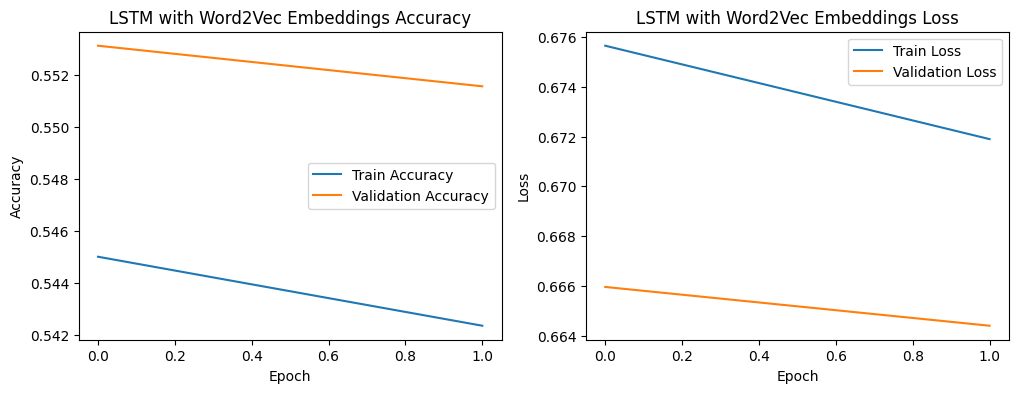

In [28]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + ' Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(word2vec_lstm_history, "LSTM with Word2Vec Embeddings")

Evaluate Word2Vec LSTM on test data

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Word2Vec LSTM Test Accuracy: 0.5515

Classification Report:
              precision    recall  f1-score   support

        fake       0.53      0.99      0.69      2000
        true       0.90      0.12      0.20      2000

    accuracy                           0.55      4000
   macro avg       0.71      0.55      0.45      4000
weighted avg       0.71      0.55      0.45      4000



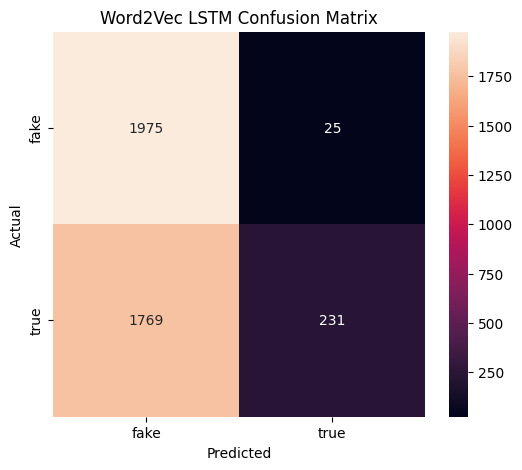

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

word2vec_probs = word2vec_lstm_model.predict(X_test_pad)
word2vec_preds = (word2vec_probs > 0.5).astype("int32").flatten()

word2vec_test_acc = accuracy_score(y_test, word2vec_preds)

print("Word2Vec LSTM Test Accuracy:", word2vec_test_acc)

print("\nClassification Report:")
print(classification_report(
    y_test,
    word2vec_preds,
    target_names=["fake", "true"]
))

cm = confusion_matrix(y_test, word2vec_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["fake", "true"],
    yticklabels=["fake", "true"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Word2Vec LSTM Confusion Matrix")
plt.show()

Evaluating Simple RNN and normal LSTM

In [30]:
def evaluate_text_model(model, X_test_pad, y_test, model_name):
    probs = model.predict(X_test_pad)
    preds = (probs > 0.5).astype("int32").flatten()

    acc = accuracy_score(y_test, preds)

    print(f"{model_name} Test Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        preds,
        target_names=["fake", "true"]
    ))

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["fake", "true"],
        yticklabels=["fake", "true"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return acc

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Simple RNN Test Accuracy: 0.537

Classification Report:
              precision    recall  f1-score   support

        fake       0.52      0.98      0.68      2000
        true       0.84      0.09      0.17      2000

    accuracy                           0.54      4000
   macro avg       0.68      0.54      0.42      4000
weighted avg       0.68      0.54      0.42      4000



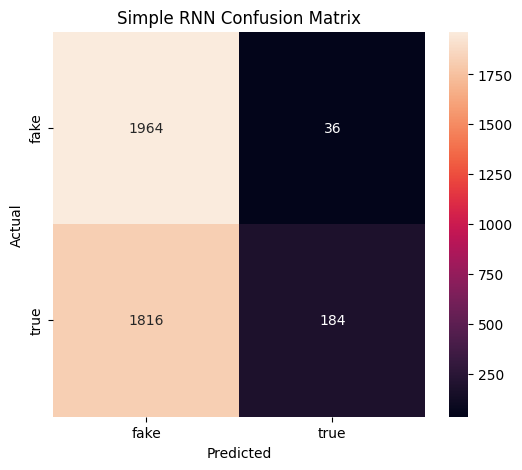

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
LSTM Test Accuracy: 0.93725

Classification Report:
              precision    recall  f1-score   support

        fake       0.92      0.95      0.94      2000
        true       0.95      0.92      0.94      2000

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000



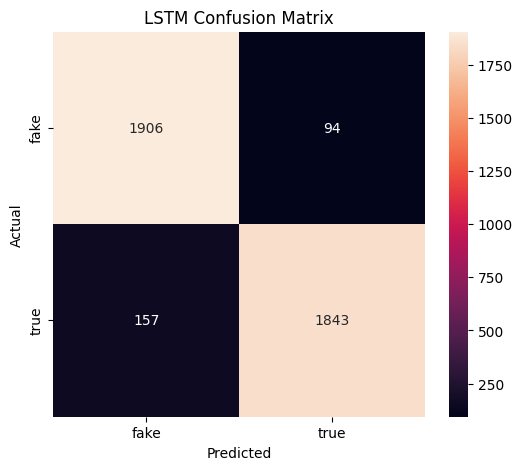

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
LSTM with Word2Vec Test Accuracy: 0.5515

Classification Report:
              precision    recall  f1-score   support

        fake       0.53      0.99      0.69      2000
        true       0.90      0.12      0.20      2000

    accuracy                           0.55      4000
   macro avg       0.71      0.55      0.45      4000
weighted avg       0.71      0.55      0.45      4000



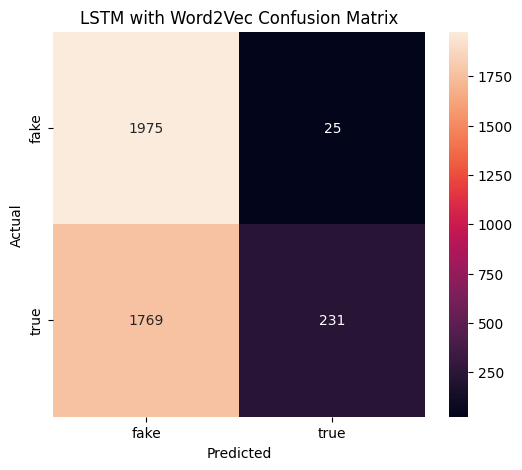

In [31]:
rnn_test_acc = evaluate_text_model(rnn_model, X_test_pad, y_test, "Simple RNN")
lstm_test_acc = evaluate_text_model(lstm_model, X_test_pad, y_test, "LSTM")
word2vec_test_acc = evaluate_text_model(word2vec_lstm_model, X_test_pad, y_test, "LSTM with Word2Vec")

In [38]:
import pandas as pd

language_comparison = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "LSTM with Word2Vec"
    ],
    "Best Validation Accuracy": [
        max(rnn_history.history['val_accuracy']),
        max(lstm_history.history['val_accuracy']),
        max(word2vec_lstm_history.history['val_accuracy'])
    ],
    "Test Accuracy": [
        rnn_test_acc,
        lstm_test_acc,
        word2vec_test_acc
    ],
    "Training Time (seconds)": [
        rnn_training_time,
        lstm_training_time,
        word2vec_lstm_training_time
    ]
})

language_comparison

,Model,Best Validation Accuracy,Test Accuracy,Training Time (seconds)
0,Simple RNN,0.541875,0.53700,31.448208
1,LSTM,0.942813,0.93725,31.109283
2,LSTM with Word2Vec,0.553125,0.55150,22.676142


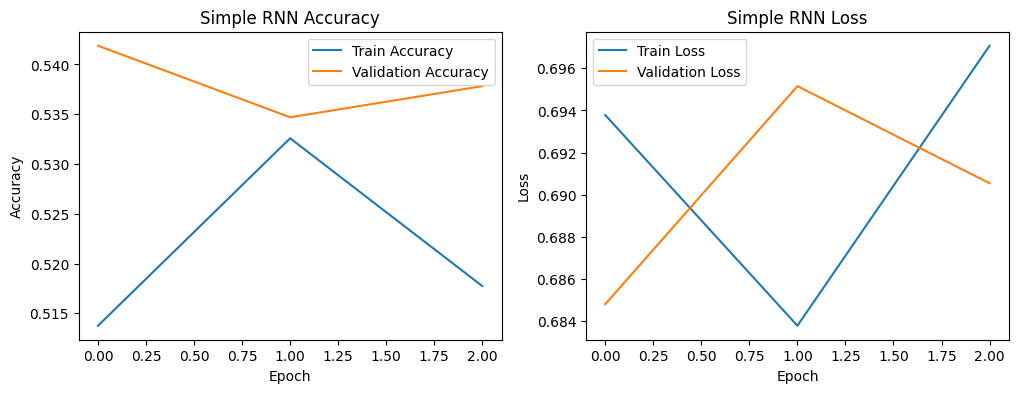

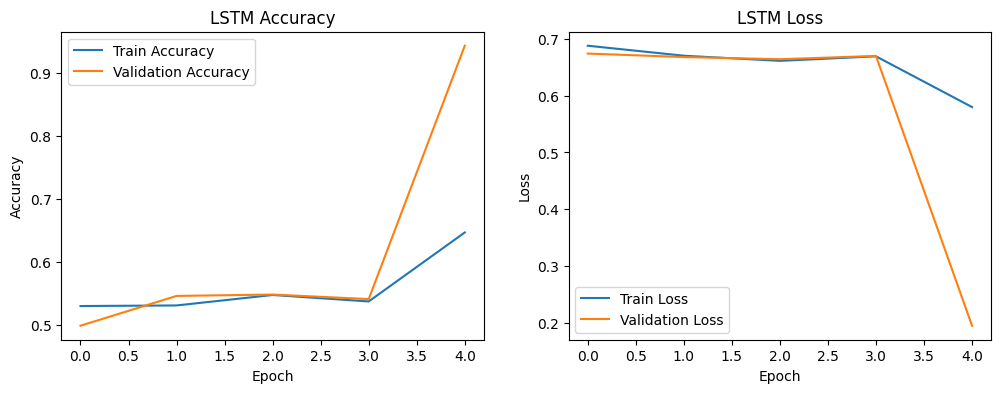

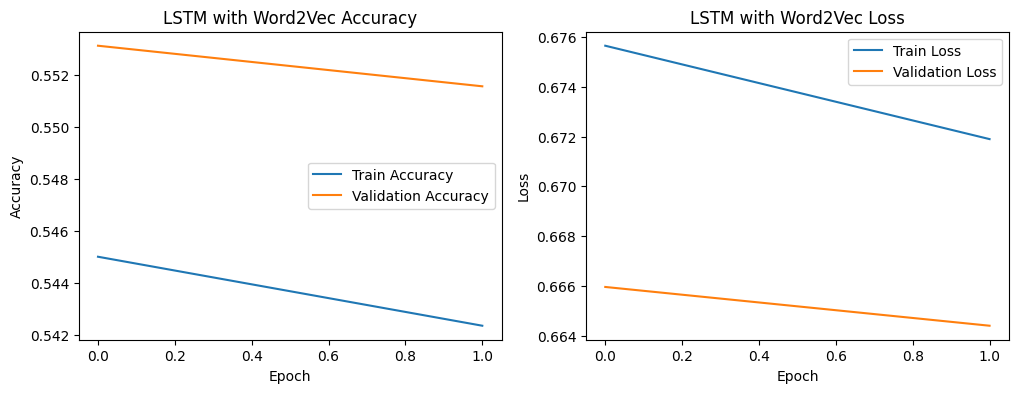

In [33]:
plot_history(rnn_history, "Simple RNN")
plot_history(lstm_history, "LSTM")
plot_history(word2vec_lstm_history, "LSTM with Word2Vec")

Incorrect Predictions

In [34]:
# Get predictions from best model
word2vec_probs = word2vec_lstm_model.predict(X_test_pad)
word2vec_preds = (word2vec_probs > 0.5).astype("int32").flatten()

# Convert y_test to array
y_test_array = y_test.values if hasattr(y_test, "values") else y_test

# Find wrong predictions
wrong_indices = np.where(word2vec_preds != y_test_array)[0]

print("Number of incorrect predictions:", len(wrong_indices))

# Show first 3 wrong predictions
for i in wrong_indices[:3]:
    print("\n--- Incorrect Prediction ---")
    print("Text:", X_test.iloc[i][:500])
    print("Actual:", "true" if y_test_array[i] == 1 else "fake")
    print("Predicted:", "true" if word2vec_preds[i] == 1 else "fake")
    print("Prediction probability:", word2vec_probs[i][0])

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Number of incorrect predictions: 1794

--- Incorrect Prediction ---
Text: hanoi reuters prominent critic vietnamese government said taken police home early tuesday would unable meet yous president barack obama hanoi civil society figure nguyen quang said forced car group police officer driven capital kept away hour time obama met six civil society leader later said several people prevented meeting obama said despite great stride made vietnam washington concern limit put political freedom
Actual: true
Predicted: fake
Prediction probability: 0.4742693

--- Incorrect Prediction ---
Text: washington reuters ohio republican governor john kasich colorado governor john hickenlooper democrat discussed idea joint run white house axios cnn reported friday citing unidentified source cnn said discussion organizational level bid would challenge republican president donald trump expected reelection campaign complicate democratic effort regain white house try

In [35]:
!pip install gradio

Creating prediction function

In [36]:
import gradio as gr
import numpy as np

def predict_news(text):
    # clean input text using the same cleaning function
    cleaned = clean_text(text)

    # tokenize and pad using same tokenizer and MAX_LEN
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    # predict using best model
    probability = word2vec_lstm_model.predict(padded)[0][0]

    if probability >= 0.5:
        label = "True News"
        confidence = probability
    else:
        label = "Fake News"
        confidence = 1 - probability

    return f"Prediction: {label}\nConfidence: {confidence:.2%}"

In [37]:
interface = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(
        lines=6,
        placeholder="Enter a news article or headline here..."
    ),
    outputs="text",
    title="Fake News Detection using LSTM with Word2Vec",
    description="Enter news text and the model will predict whether it is Fake or True."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ab90b9af5ca9ef377c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
